In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.stats.mstats import winsorize
from scipy.stats import zscore
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
import graphviz

In [ ]:
df=pd.read_csv('/content/insurance_claims.csv')

In [ ]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [ ]:
df.tail()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN
999,456,60,556080,1996-11-11,OH,250/500,1000,766.19,0,612260,...,?,5060,460,920,3680,Mercedes,E400,2007,N,NaN


In [ ]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [ ]:
df.isnull().sum()

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [ ]:
df.shape

(1000, 40)

In [ ]:
df=df.drop('_c39',axis=1)

In [ ]:
df['authorities_contacted']=df['authorities_contacted'].fillna(df['authorities_contacted'].mode()[0])

In [ ]:
df.isnull().sum()

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [ ]:
numeric_cols = df.select_dtypes(include=np.number)
z = zscore(numeric_cols)
outliers_zscore = df[(np.abs(z)>3).any(axis=1)]
for i in range(len(df)):

    cols = numeric_cols.columns[z[i] > 3]

    if len(cols) > 0:
        print("Row", i, "->", list(cols))

Row 31 -> ['umbrella_limit']
Row 48 -> ['umbrella_limit']
Row 88 -> ['umbrella_limit']
Row 115 -> ['umbrella_limit']
Row 119 -> ['umbrella_limit']
Row 229 -> ['policy_annual_premium']
Row 262 -> ['umbrella_limit']
Row 314 -> ['umbrella_limit']
Row 430 -> ['umbrella_limit']
Row 458 -> ['umbrella_limit']
Row 500 -> ['property_claim']
Row 503 -> ['umbrella_limit']
Row 657 -> ['umbrella_limit']
Row 700 -> ['umbrella_limit']
Row 875 -> ['umbrella_limit']
Row 922 -> ['umbrella_limit']
Row 975 -> ['umbrella_limit']


In [ ]:
outliers_zscore

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
31,166,37,666333,2008-06-19,IL,100/300,2000,1337.28,8000000,610393,...,2,?,67140,7460,7460,52220,Ford,F150,2006,Y
48,175,34,866931,2008-01-07,IN,500/1000,1000,1123.87,8000000,446326,...,0,YES,7290,810,810,5670,Volkswagen,Passat,1995,N
88,31,36,679370,1999-08-15,IL,500/1000,2000,1318.24,9000000,601748,...,1,YES,4700,940,470,3290,Dodge,Neon,2002,N
115,258,46,648397,1999-03-09,IN,100/300,1000,1110.37,10000000,455365,...,1,?,47700,4770,9540,33390,Accura,MDX,1997,Y
119,245,39,531640,2001-04-21,OH,250/500,500,964.79,8000000,460675,...,1,?,72820,13240,6620,52960,BMW,3 Series,2010,N
229,154,37,241562,2010-01-28,IL,250/500,1000,2047.59,0,439269,...,3,NO,79530,14460,7230,57840,Accura,MDX,2000,N
248,101,27,326322,2007-02-10,IL,250/500,1000,433.33,0,603269,...,3,NO,5900,1180,590,4130,Mercedes,E400,2009,N
262,232,43,751905,2001-05-16,OH,250/500,500,1483.91,8000000,431531,...,1,?,70600,7060,14120,49420,Volkswagen,Passat,2013,Y
314,91,30,515217,2010-06-18,IL,250/500,2000,1316.63,8000000,613178,...,0,?,84500,13000,13000,58500,BMW,X6,2009,N
430,264,47,687639,2005-03-07,IN,250/500,2000,1181.46,10000000,601117,...,2,YES,62370,5670,5670,51030,Dodge,Neon,2001,N


In [ ]:
Q1=numeric_cols.quantile(0.25)
Q3=numeric_cols.quantile(0.75)
IQR=Q3-Q1

In [ ]:
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

In [ ]:
outlier=numeric_cols[(numeric_cols<lower)|(numeric_cols>upper)]

In [ ]:
outlier

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,5000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,5000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,6000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,6000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,3000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
998,NaN,NaN,NaN,NaN,NaN,5000000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


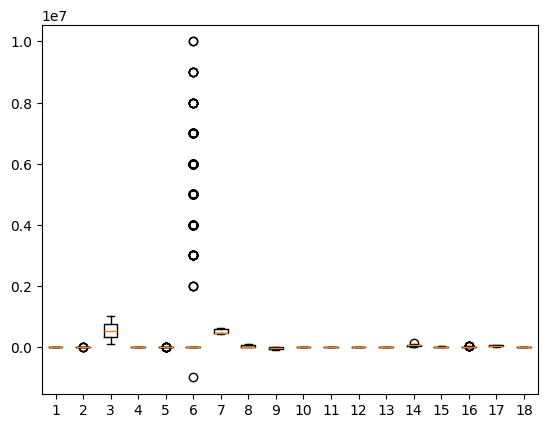

In [ ]:
plt.boxplot(numeric_cols)
plt.show()

In [ ]:
s=StandardScaler()
df[['umbrella_limit']]=s.fit_transform(df[['umbrella_limit']])

In [ ]:
df[['policy_annual_premium']]=s.fit_transform(df[['policy_annual_premium']])

In [ ]:
l=LabelEncoder()
df['policy_bind_date']=l.fit_transform(df['policy_bind_date'])
df['insured_sex']=l.fit_transform(df['insured_sex'])

In [ ]:
model=DecisionTreeClassifier(criterion='entropy')
x=df[['age','umbrella_limit','policy_annual_premium','policy_bind_date','insured_sex']]
y=df['fraud_reported']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
a=accuracy_score(y_test,y_pred)

In [ ]:
a

0.59

In [ ]:
graph=tree.export_graphviz(model)

In [ ]:
ori=graphviz.Source(graph)

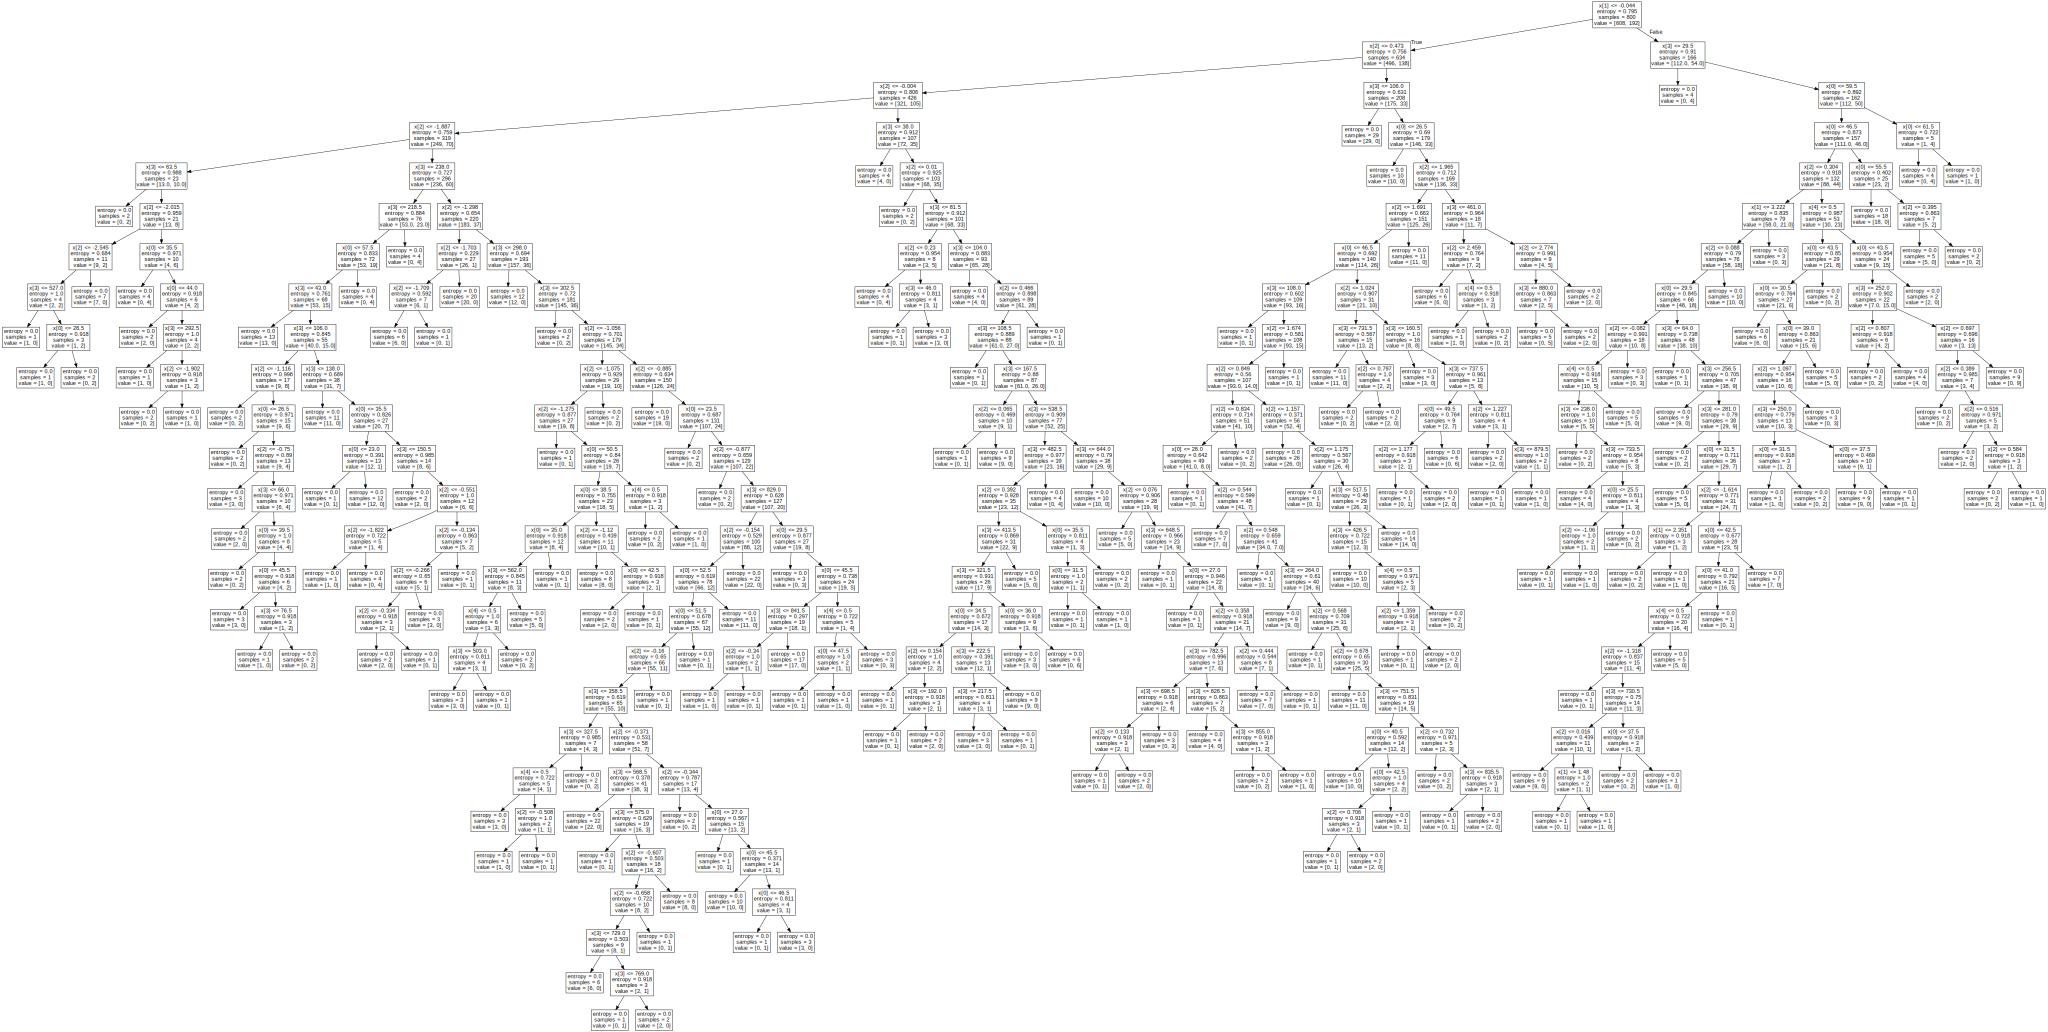

In [ ]:
ori